In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import levy_stable
import powerlaw
import math
from datetime import datetime

def pl_fit(data):
    """
    Calculate exponent of powerlaw and standard deviation of parameter uncertainty for alpha
    """
    result = powerlaw.Fit(data).power_law
    alpha = result.alpha
    sigma = result.sigma

    return alpha, sigma

def crit_params(data):
    """
    Fit data to Levy stable distribution and output alpha and beta estimates.
    Alpha is the stability parameter and beta is the skewness parameter.
    """

    alpha_est, beta_est, loc_est, scale_est = levy_stable.fit(data)
    return alpha_est, beta_est

## Load data
Frequency of data is daily. 

In [3]:
# Extract raw CSV data 
months = ['2022-01','2022-02','2022-03','2022-04','2022-05','2022-06',
          '2022-07','2022-08','2022-09','2022-10','2022-11','2022-12',
          '2023-01','2023-02','2023-03','2023-04','2023-05','2023-06',
          '2023-07','2023-08','2023-09','2023-10','2023-11','2023-12',
          '2024-01','2024-02','2024-03','2024-04','2024-05','2024-06',
          '2024-07','2024-08','2024-09','2024-10','2024-11','2024-12',
          '2025-01','2025-02','2025-03','2025-04','2025-05','2025-06',
          '2025-07','2025-08','2025-09','2025-10','2025-11','2025-12',
          '2026-01','2026-02','2026-03','2026-04','2026-05','2026-06']

for i, month in enumerate(months):
    if i == 0:
        df = pd.read_csv('Data/Bitcoin/BTCUSDT-1d-' + month + '.csv', header=None)
    
    if i > 0:
        df_to_add = pd.read_csv('Data/Bitcoin/BTCUSDT-1d-' + month + '.csv', header=None)
        df = pd.concat([df, df_to_add], ignore_index=True)

# Keep only close time and close price (column 4)
df = df[[6,4]]
df.columns = ['Timestamp', 'Price']
print(df.head())

       Timestamp     Price
0  1641081599999  47722.65
1  1641167999999  47286.18
2  1641254399999  46446.10
3  1641340799999  45832.01
4  1641427199999  43451.13


## Clean data

In [4]:
# Clean up timestamps in df
dates = []

# Timestamps before 2 Jan 2025 are in milliseconds
for timestamp in np.array(df[df['Timestamp'] < 1E13]['Timestamp']):
    dates.append(datetime.fromtimestamp(timestamp / 1E3).date().strftime("%Y-%m-%d"))

# Timestamps from 2 Jan 2025 onwards are in microseconds
for timestamp in np.array(df[df['Timestamp'] >= 1E13]['Timestamp']):
    dates.append(datetime.fromtimestamp(timestamp / 1E6).date().strftime("%Y-%m-%d"))

df['Date'] = dates
df = df[['Date','Price']]
print(df.head())

         Date     Price
0  2022-01-02  47722.65
1  2022-01-03  47286.18
2  2022-01-04  46446.10
3  2022-01-05  45832.01
4  2022-01-06  43451.13


## Visualize return distribution

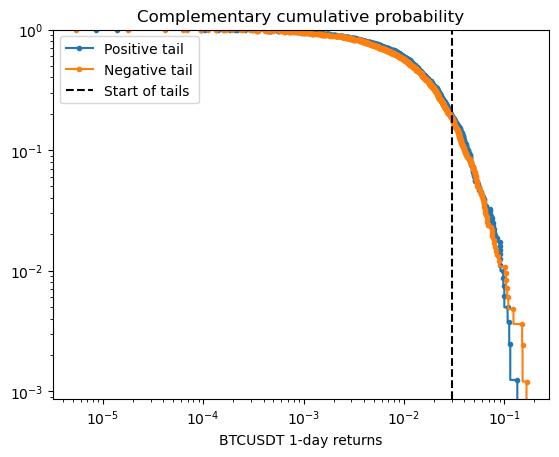

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
sample sizes: 155, 155
3.712538391977177+-0.24761974423078167, 3.3184194005644123+-0.1862199275035881


In [23]:
# Plot returns CCDF
cutoff = 3E-2 # Cutoff point at which the power-law tail starts was selected visually from the log-log plot of CCDF of returns

gains = []
losses = []
filteredgains = []
filteredlosses = []

# Find the 'return' r. Separate r values into gains and losses.
for j, price in enumerate(df['Price']):
    if j < len(df['Price'])-1:
        r = math.log(df['Price'][j+1]) - math.log(price)
        if r >= 0:
            gains.append(r)
            if r >= cutoff:
                filteredgains.append(r)
        else:
            losses.append(abs(r))
            if r <= -cutoff:
                filteredlosses.append(abs(r))

# Plot the complementary cumulative probability distribution of 'returns'
plt.ecdf(gains,complementary=True, marker='.', label='Positive tail')
plt.ecdf(losses,complementary=True, marker='.', label='Negative tail')

plt.title('Complementary cumulative probability')
plt.xlabel('BTCUSDT 1-day returns')
plt.xscale('log')
plt.yscale('log')
plt.axvline(cutoff, color='k', ls='--', label='Start of tails')
plt.legend()
plt.show()

# Calculate exponent of tail values.
gain_alpha, gain_u= pl_fit(filteredgains)
loss_alpha, loss_u = pl_fit(filteredlosses)
print(f'sample sizes: {len(filteredgains)}, {len(filteredlosses)}')
print(f'{gain_alpha}+-{gain_u}, {loss_alpha}+-{loss_u}')

## Estimation of Levy stable parameters

### 1 day before 10 October 2025 Bitcoin crash

In [ ]:
# Set time window of our study
crisisdate = '2025-10-10' # Date of crisis we want to study
window = 500 # Number of latest consecutive days to use in estimation of Levy stable parameters

crisisrow = np.where(df['Date'] == crisisdate)[0][0] # Row in df corresponding to crisisdate
windowrowend = crisisrow - 1 # Row in df corresponding to end of window, ie. 1 day before the crisis
windowrowstart = crisisrow - 1 - window # Row in df corresponding to start of window
windowprices = np.array(df['Price'].iloc[windowrowstart:windowrowend])
filteredreturns = []
returns = []

# Find the 'return' r
for j, price in enumerate(windowprices):
    if j < len(windowprices)-1:
        r = math.log(windowprices[j+1]) - math.log(price)

        returns.append(r)

print(f'no. of returns = {len(returns)}')
print(f'time period of window: {df['Date'].iloc[windowrowstart]} to {df['Date'].iloc[windowrowend]}')
print(f'alpha, beta = {crit_params(returns)}')

no. of returns = 499
time period of window: 2024-05-27 to 2025-10-09
alpha, beta = (np.float64(1.6626828516639782), np.float64(0.037216470350292824))


### On different days before 10 October 2025 Bitcoin crash

Calculation of returns for days_bef_crisis=10 done.
days_bef_crisis=10, alpha=1.6418006655043118, beta=0.1092569868760036
Calculation of returns for days_bef_crisis=5 done.
days_bef_crisis=5, alpha=1.6635974484214455, beta=0.07553562108774534
Calculation of returns for days_bef_crisis=1 done.
days_bef_crisis=1, alpha=1.6626828516639782, beta=0.037216470350292824


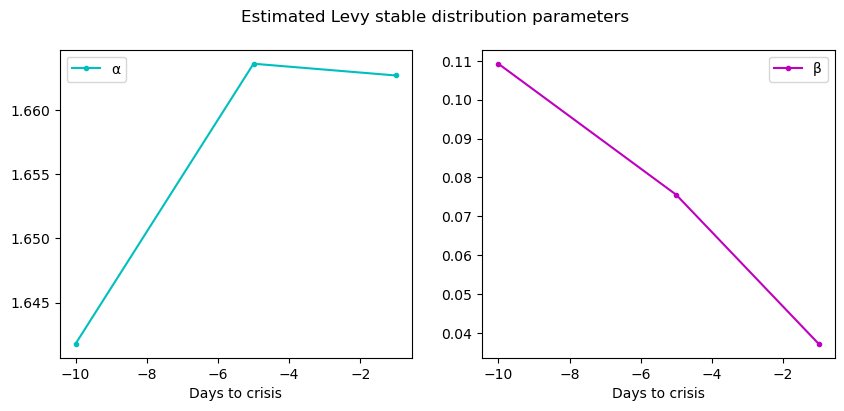

In [15]:
days_grid = [10, 5, 1] # No. of market days before crisis. Minimum value is 1
crisisdate = '2025-10-10' # Date of crisis we want to study
window = 500 # Number of latest consecutive market days to use in estimation of Levy stable parameters, up to crisisdate

crisisrow = np.where(df['Date'] == crisisdate)[0][0] # Row in df corresponding to crisisdate
neg_days_grid = neg_days_grid = [-day for day in days_grid] # Get negative days
alphas = []
betas = []

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))

for days_bef_crisis in days_grid:
    windowrowend = crisisrow - days_bef_crisis
    windowrowstart = crisisrow - days_bef_crisis - window
    windowprices = np.array(df['Price'].iloc[windowrowstart:windowrowend])

    returns = []

    # Find the return, r
    for j, price in enumerate(windowprices):
        if j < len(windowprices)-1:
            r = math.log(windowprices[j+1]) - math.log(price)

            returns.append(r)

    print(f'Calculation of returns for days_bef_crisis={days_bef_crisis} done.')
    alpha, beta = crit_params(returns)
    print(f'days_bef_crisis={days_bef_crisis}, alpha={alpha}, beta={beta}')
    alphas.append(alpha)
    betas.append(beta)
ax1.plot(neg_days_grid, alphas, color='c', marker='.', label='α')
ax2.plot(neg_days_grid, betas, color = 'm', marker='.', label='β')
fig.suptitle('Estimated Levy stable distribution parameters')
ax1.set_xlabel('Days to crisis')
ax2.set_xlabel('Days to crisis')
ax1.legend()
ax2.legend()
plt.show()

### 1 day before 3 June 2026 Bitcoin crash

In [ ]:
# Set time window of our study
crisisdate = '2026-06-03' # Date of crisis we want to study
window = 500 # Number of latest consecutive days to use in estimation of Levy stable parameters, up to crisisdate

crisisrow = np.where(df['Date'] == crisisdate)[0][0] # Row in df corresponding to crisisdate
windowrowend = crisisrow - 1 # Row in df corresponding to end of window, ie. 1 day before the crisis
windowrowstart = crisisrow - 1 - window # Row in df corresponding to start of window
windowprices = np.array(df['Price'].iloc[windowrowstart:windowrowend])
filteredreturns = []
returns = []

# Find the 'return' r
for j, price in enumerate(windowprices):
    if j < len(windowprices)-1:
        r = math.log(windowprices[j+1]) - math.log(price)

        returns.append(r)

print(f'no. of returns = {len(returns)}')
print(f'time period of window: {df['Date'].iloc[windowrowstart]} to {df['Date'].iloc[windowrowend]}')
print(f'alpha, beta = {crit_params(returns)}')

no. of returns = 499
time period of window: 2025-01-18 to 2026-06-02
alpha, beta = (np.float64(1.6589410674067788), np.float64(-0.021549648876427203))


### On different days before 3 June 2026 Bitcoin crash

Calculation of returns for days_bef_crisis=60 done.
days_bef_crisis=60, alpha=1.671820033140912, beta=-0.038080974760317535
Calculation of returns for days_bef_crisis=50 done.
days_bef_crisis=50, alpha=1.6729739306591362, beta=-0.036884037435583605
Calculation of returns for days_bef_crisis=40 done.
days_bef_crisis=40, alpha=1.6739064222444207, beta=-0.018658681395315884
Calculation of returns for days_bef_crisis=15 done.
days_bef_crisis=15, alpha=1.669358947383607, beta=-0.007200111705254744
Calculation of returns for days_bef_crisis=3 done.
days_bef_crisis=3, alpha=1.6632705222305213, beta=-0.003217703980915432


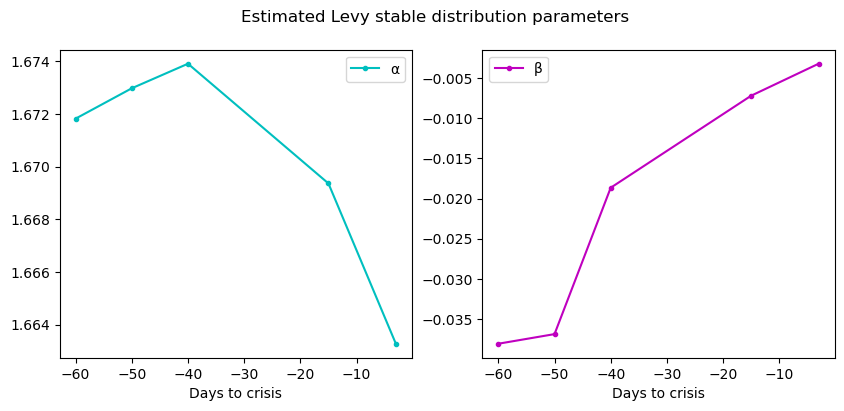

In [13]:
days_grid = [60, 50, 40, 15, 3] # No. of market days before crisis. Minimum value is 1
crisisdate = '2026-06-03' # Date of crisis we want to study
window = 500 # Number of latest consecutive days to use in estimation of Levy stable parameters, up to crisisdate

crisisrow = np.where(df['Date'] == crisisdate)[0][0] # Row in df corresponding to crisisdate
neg_days_grid = neg_days_grid = [-day for day in days_grid] # Get negative days
alphas = []
betas = []

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))

for days_bef_crisis in days_grid:
    windowrowend = crisisrow - days_bef_crisis
    windowrowstart = crisisrow - days_bef_crisis - window
    windowprices = np.array(df['Price'].iloc[windowrowstart:windowrowend])

    returns = []

    # Find the return, r
    for j, price in enumerate(windowprices):
        if j < len(windowprices)-1:
            r = math.log(windowprices[j+1]) - math.log(price)

            returns.append(r)

    print(f'Calculation of returns for days_bef_crisis={days_bef_crisis} done.')
    alpha, beta = crit_params(returns)
    print(f'days_bef_crisis={days_bef_crisis}, alpha={alpha}, beta={beta}')
    alphas.append(alpha)
    betas.append(beta)
ax1.plot(neg_days_grid, alphas, color='c', marker='.', label='α')
ax2.plot(neg_days_grid, betas, color = 'm', marker='.', label='β')
fig.suptitle('Estimated Levy stable distribution parameters')
ax1.set_xlabel('Days to crisis')
ax2.set_xlabel('Days to crisis')
ax1.legend()
ax2.legend()
plt.show()